# Results Report — Stages 1–4 (post-v2 rewrite)

**Project.** CoT distillation + ReCEval, FLAN-T5-base on GSM8K (Magister et al. ACL 2023; Prasad et al. EMNLP 2023).

**Status.** Stages 1–4 complete for all five conditions: `baseline`, `student_direct_ft`, `student_set_a`, `student_set_b`, `student_set_c`. Stage 5a (accuracy) is computed inline below; Stage 5b (ReCEval) is the next checkpoint.

**Purpose.** Snapshot the current state of the pipeline: training health, decoding quality, accuracy, and the qualitative behaviour of each student. Surface what is working, what is broken, and what is open.

All numbers in this notebook are reconstructed from `outputs/runs/*.json`, `outputs/checkpoints/*/loss_log.csv`, and `outputs/generations/*.jsonl`. Nothing is hard-coded; re-run the notebook after any new run and the tables / plots update.


## 0. Setup

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data.parse_answer import parse_answer
from src.data.calculator import correct_equations

GEN  = ROOT / "outputs" / "generations"
CKPT = ROOT / "outputs" / "checkpoints"
RUNS = ROOT / "outputs" / "runs"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CONDS = ["baseline", "student_direct_ft", "student_set_a", "student_set_b", "student_set_c"]
STUDENT_RUNS = ["student_direct_ft", "student_set_a", "student_set_b", "student_set_c"]

PALETTE = {
    "baseline":          "#7f7f7f",
    "student_direct_ft": "#9467bd",
    "student_set_a":     "#1f77b4",
    "student_set_b":     "#2ca02c",
    "student_set_c":     "#d62728",
}

def load_runcard(name):
    p = RUNS / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None

def load_records(cond):
    with (GEN / f"{cond}.jsonl").open() as f:
        return [json.loads(line) for line in f]


## 1. Artifact integrity check

Confirm every expected artifact made it into the codespace before we draw conclusions from anything.

In [2]:
expected = {
    "runs/02_filter.json":                              RUNS / "02_filter.json",
    "runs/03_train_student_direct_ft.json":             RUNS / "03_train_student_direct_ft.json",
    "runs/03_train_student_set_a.json":                 RUNS / "03_train_student_set_a.json",
    "runs/03_train_student_set_b.json":                 RUNS / "03_train_student_set_b.json",
    "runs/03_train_student_set_c.json":                 RUNS / "03_train_student_set_c.json",
    "runs/04_inference_baseline.json":                  RUNS / "04_inference_baseline.json",
    "runs/04_inference_student_direct_ft.json":         RUNS / "04_inference_student_direct_ft.json",
    "runs/04_inference_student_set_a.json":             RUNS / "04_inference_student_set_a.json",
    "runs/04_inference_student_set_b.json":             RUNS / "04_inference_student_set_b.json",
    "runs/04_inference_student_set_c.json":             RUNS / "04_inference_student_set_c.json",
    "generations/baseline.jsonl":                       GEN  / "baseline.jsonl",
    "generations/student_direct_ft.jsonl":              GEN  / "student_direct_ft.jsonl",
    "generations/student_set_a.jsonl":                  GEN  / "student_set_a.jsonl",
    "generations/student_set_b.jsonl":                  GEN  / "student_set_b.jsonl",
    "generations/student_set_c.jsonl":                  GEN  / "student_set_c.jsonl",
    "checkpoints/student_direct_ft/loss_log.csv":       CKPT / "student_direct_ft/loss_log.csv",
    "checkpoints/student_set_a/loss_log.csv":           CKPT / "student_set_a/loss_log.csv",
    "checkpoints/student_set_b/loss_log.csv":           CKPT / "student_set_b/loss_log.csv",
    "checkpoints/student_set_c/loss_log.csv":           CKPT / "student_set_c/loss_log.csv",
}
rows = [{"artifact": k, "present": p.exists(), "size_kb": (p.stat().st_size // 1024) if p.exists() else 0}
        for k, p in expected.items()]
df_integrity = pd.DataFrame(rows)
missing = df_integrity[~df_integrity.present]
print(f"Present : {df_integrity.present.sum()} / {len(df_integrity)}")
print(f"Missing : {len(missing)}")
df_integrity


Present : 19 / 19
Missing : 0


,artifact,present,size_kb
0,runs/02_filter.json,True,3
1,runs/03_train_student_direct_ft.json,True,1
2,runs/03_train_student_set_a.json,True,1
3,runs/03_train_student_set_b.json,True,1
4,runs/03_train_student_set_c.json,True,1
5,runs/04_inference_baseline.json,True,2
6,runs/04_inference_student_direct_ft.json,True,2
7,runs/04_inference_student_set_a.json,True,2
8,runs/04_inference_student_set_b.json,True,2
9,runs/04_inference_student_set_c.json,True,2


## 2. Stage 2 — filter statistics

Set A is the unfiltered Ho et al. teacher pool. Set B keeps chains whose teacher final answer matches gold (Magister-style answer-correctness filter). Set C is the *process-aware* filter: rewrite each `A op B = C` in the chain via the calculator, then keep iff the rewritten chain's final answer matches gold. Set C is **stricter** than Set B by design — it rejects chains that arrived at the right answer through wrong arithmetic, and adds chains rescued from arithmetic slips.

Set sizes and the B↔C overlap matrix come straight out of `runs/02_filter.json`.

In [3]:
rc2 = load_runcard("02_filter")
m   = rc2["metrics"]

filter_summary = pd.DataFrame([
    {"set": "A — no filter",          "size": m["set_a_size"],     "keep_rate": 1.0},
    {"set": "B — answer-correct",     "size": m["set_b_size"],     "keep_rate": m["set_b_keep_rate"]},
    {"set": "C — calculator-correct", "size": m["set_c_size"],     "keep_rate": m["set_c_keep_rate"]},
    {"set": "Direct FT (Q→A only)",   "size": m["direct_ft_size"], "keep_rate": 1.0},
])
print(f"GSM8K train rows ........... {m['gsm8k_train_rows']:,}")
print(f"Calculator-edited chains ... {m['n_calculator_edited']:,}")
print(f"Skipped (unparseable) ...... {m['skipped_unparseable_teacher_pred']}")
print()
filter_summary


GSM8K train rows ........... 7,473
Calculator-edited chains ... 676
Skipped (unparseable) ...... 78



,set,size,keep_rate
0,A — no filter,7473,1.0000
1,B — answer-correct,3389,0.4535
2,C — calculator-correct,2635,0.3526
3,Direct FT (Q→A only),7473,1.0000


In [4]:
overlap = pd.DataFrame(
    [[m["contingency_b_and_c"], m["contingency_b_only"]],
     [m["contingency_c_only"],  m["contingency_neither"]]],
    index=["in C",     "not in C"],
    columns=["in B",   "not in B"],
)
print("B ↔ C contingency (rows = C membership, cols = B membership)\n")
print(overlap)


B ↔ C contingency (rows = C membership, cols = B membership)

          in B  not in B
in C      2585       804
not in C    50      4034


**Observations.**

- **Yields are roughly half (B) and one-third (C)** of the raw teacher pool. Ho et al.'s text-davinci-002 zero-shot CoTs land the right answer ~45% of the time on GSM8K, which is consistent with the Magister-style yield reported in the v2 plan.
- **Set C ⊊ Set B in spirit but not exactly.** 50 chains are in C but *not* in B — these are chains where the teacher's stated final number was wrong, but the underlying arithmetic was right and the calculator-rewritten final answer matches gold. Conversely, 804 chains are in B but not in C — they reach the right final number through wrong arithmetic and Set C correctly rejects them.
- **676 chains were edited by the calculator** during Set C construction. Set C therefore contains 2,635 − 50 = 2,585 chains shared with Set B (some with arithmetic patched in-place) plus 50 net-new rescues.


## 3. Stage 3 — training summary

Compact view of the four student runs: train/val sizes, wall-clock duration, best epoch (after early-stopping with patience 2), best eval loss.

In [5]:
rows = []
for r in STUDENT_RUNS:
    rc = load_runcard(f"03_train_{r}")
    if rc is None: continue
    rows.append({
        "run":             r,
        "n_train":         rc["metrics"]["n_train"],
        "n_val":           rc["metrics"]["n_val"],
        "epochs_run":      round(rc["metrics"]["n_epochs_completed"], 2),
        "best_epoch":      round(rc["metrics"]["best_epoch"], 2),
        "best_eval_loss":  round(rc["metrics"]["best_eval_loss"], 4),
        "early_stopped":   rc["metrics"].get("early_stopped", False),
        "duration_min":    round(rc["duration_seconds"] / 60, 1),
    })
df_train = pd.DataFrame(rows)
df_train


,run,n_train,n_val,epochs_run,best_epoch,best_eval_loss,early_stopped,duration_min
0,student_direct_ft,6725,748,7.99,7.99,0.8675,True,39.6
1,student_set_a,6725,748,7.99,7.99,0.9223,True,57.2
2,student_set_b,3050,339,7.87,6.99,0.9217,True,25.2
3,student_set_c,2371,264,7.97,7.97,0.8877,True,19.9


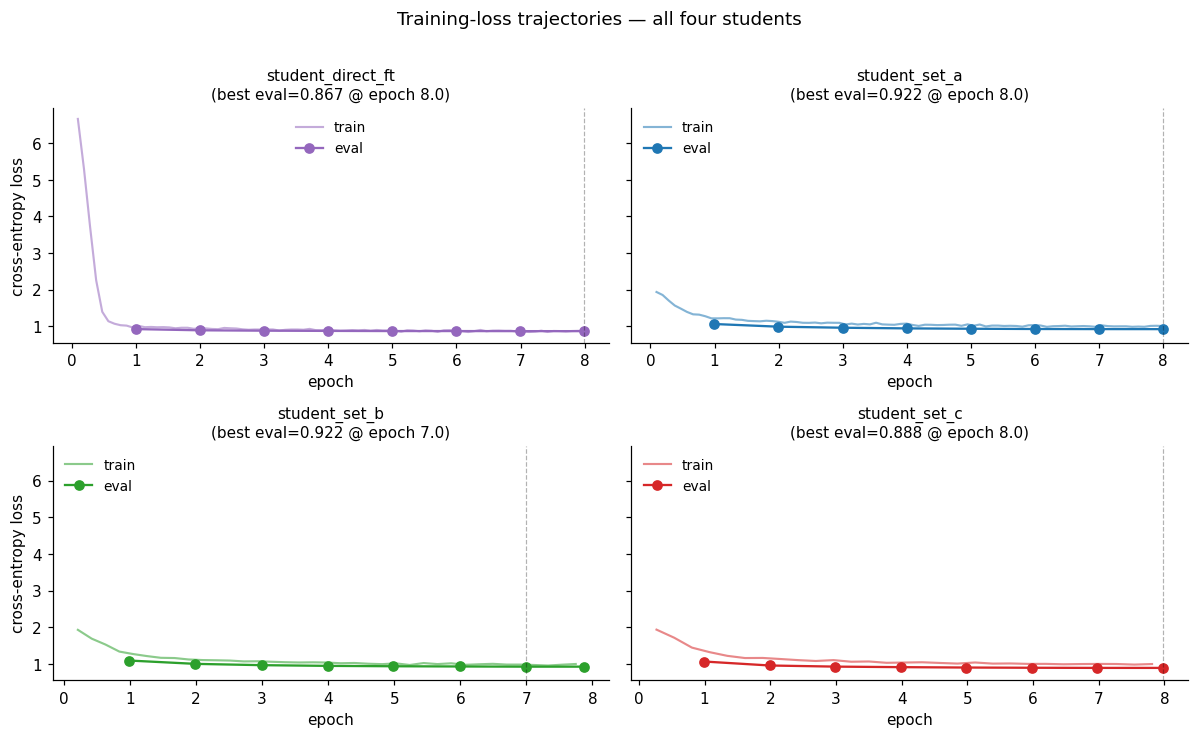

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.6), sharey=True)
for ax, run in zip(axes.flat, STUDENT_RUNS):
    log = pd.read_csv(CKPT / run / "loss_log.csv").drop_duplicates(subset=["step", "kind"], keep="last")
    train = log[log["kind"] == "train"]
    evald = log[log["kind"] == "eval"]
    ax.plot(train.epoch, train.loss, label="train", color=PALETTE[run], alpha=0.55, linewidth=1.4)
    ax.plot(evald.epoch, evald.loss, marker="o", color=PALETTE[run], label="eval")
    rc = load_runcard(f"03_train_{run}")
    best_ep = rc["metrics"]["best_epoch"]
    best_loss = rc["metrics"]["best_eval_loss"]
    ax.axvline(best_ep, ls="--", color="black", alpha=0.3, linewidth=0.8)
    ax.set_title(f"{run}\n(best eval={best_loss:.3f} @ epoch {best_ep:.1f})", fontsize=10)
    ax.set_xlabel("epoch")
    ax.legend(frameon=False, fontsize=9)
axes[0, 0].set_ylabel("cross-entropy loss")
axes[1, 0].set_ylabel("cross-entropy loss")
fig.suptitle("Training-loss trajectories — all four students", y=1.01)
plt.tight_layout()
plt.show()


**Observations.**

- **All four runs are healthy.** Train and eval loss both decrease monotonically; no NaN, no divergence, no plateau at random-baseline level. The v2 recipe (`lr=5e-5`, `wd=0.01`, `max_in/out=512/512`) reached its planned 8 epochs (early-stopped just under in every case).
- **`student_direct_ft` reaches the lowest eval loss (~0.87)** — and that makes sense, because its target is short (`#### {answer}`) so the per-token cross-entropy can be very low even when most predictions are wrong.
- **Set A's eval loss is the highest of the CoT runs** (~0.92) — it has the noisiest targets (no answer filter), and the longer chain length means more tokens to fit.
- **Set B and Set C land within ~3% of each other on val loss** (0.922 vs 0.888) despite Set C having only 78% as many training rows. That is the first quantitative hint that Set C's chains are easier to fit because their arithmetic is internally consistent.
- **Set B's best epoch is 7.0**, the others are at 8.0. Early stopping triggered for Set B but not the others — minor, mentioned for completeness.


## 4. Stage 5a — accuracy and accuracy-with-calculator

Final-answer accuracy on the GSM8K test set (1,319 problems), computed two ways:

- **`accuracy`**: parse the final number directly from the generated CoT, compare to gold within `1e-6`.
- **`accuracy_w_calc`**: run the generated CoT through `src.data.calculator.correct_equations` first, *then* parse and compare. This catches arithmetic slips on the surface (e.g. the model said `5 * 4 = 18`); it does **not** rescue chains that used the wrong inputs.

Stage 5a hasn't been formally written to `outputs/eval_results/accuracy.csv` yet, so we compute everything inline here from the generation files.

In [7]:
def metrics_for(cond):
    rs = load_records(cond)
    n = len(rs)
    correct = correct_calc = parsed = has_eos = 0
    cot_chars = []
    for r in rs:
        cot = r["generated_cot"] or ""
        pa  = r["parsed_answer"]
        ga  = r["gold_answer"]
        if pa is not None: parsed += 1
        if pa is not None and ga is not None and abs(pa - ga) < 1e-6: correct += 1
        rewritten, _ = correct_equations(cot)
        pa2 = parse_answer(rewritten)
        if pa2 is not None and ga is not None and abs(pa2 - ga) < 1e-6: correct_calc += 1
        if "####" in cot: has_eos += 1
        cot_chars.append(len(cot))
    return {
        "condition":           cond,
        "n":                   n,
        "accuracy":            correct / n,
        "accuracy_w_calc":     correct_calc / n,
        "parse_rate":          parsed / n,
        "format_compliance":   has_eos / n,
        "median_chars":        int(np.median(cot_chars)),
        "_cot_chars":          cot_chars,
    }

rows = [metrics_for(c) for c in CONDS]
df_acc = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in rows])
df_show = df_acc.copy()
for col in ["accuracy", "accuracy_w_calc", "parse_rate", "format_compliance"]:
    df_show[col] = df_show[col].map(lambda x: f"{x:.2%}")
df_show


,condition,n,accuracy,accuracy_w_calc,parse_rate,format_compliance,median_chars
0,baseline,1319,4.32%,4.32%,100.00%,0.00%,241
1,student_direct_ft,1319,5.00%,5.00%,100.00%,100.00%,7
2,student_set_a,1319,2.50%,2.50%,100.00%,100.00%,308
3,student_set_b,1319,3.03%,3.03%,99.92%,99.85%,263
4,student_set_c,1319,3.18%,3.18%,99.85%,100.00%,258


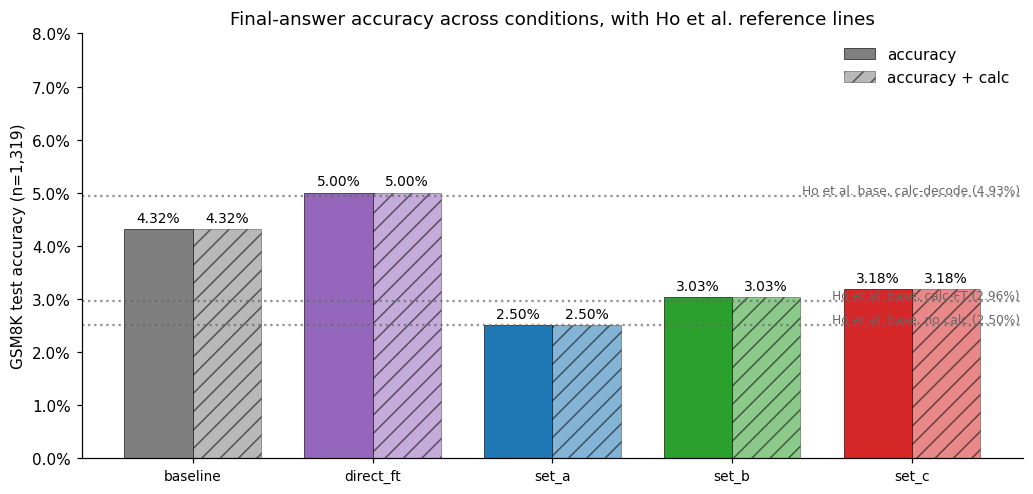

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x = np.arange(len(CONDS))
w = 0.38

acc      = [r["accuracy"]        for r in rows]
acc_calc = [r["accuracy_w_calc"] for r in rows]
colors   = [PALETTE[c] for c in CONDS]

b1 = ax.bar(x - w/2, acc,      w, label="accuracy",          color=colors,      edgecolor="black", linewidth=0.4)
b2 = ax.bar(x + w/2, acc_calc, w, label="accuracy + calc",   color=colors,      edgecolor="black", linewidth=0.4, alpha=0.55, hatch="//")

for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 0.0008,
                f"{r.get_height():.2%}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.0250, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0254, "Ho et al. base, no calc (2.50%)", fontsize=8, ha="right", color="#666")
ax.axhline(0.0296, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0300, "Ho et al. base, calc-FT (2.96%)", fontsize=8, ha="right", color="#666")
ax.axhline(0.0493, ls=":", color="#666", alpha=0.7)
ax.text(len(CONDS) - 0.4, 0.0497, "Ho et al. base, calc-decode (4.93%)", fontsize=8, ha="right", color="#666")

ax.set_xticks(x); ax.set_xticklabels([c.replace("student_", "") for c in CONDS], fontsize=9)
ax.set_ylabel("GSM8K test accuracy (n=1,319)")
ax.set_ylim(0, max(acc + acc_calc) * 1.6)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="upper right", frameon=False)
ax.set_title("Final-answer accuracy across conditions, with Ho et al. reference lines")
plt.tight_layout(); plt.show()


**Observations.**

- **Direct FT (5.00%) is the highest-accuracy condition** — and it does it without producing any reasoning at all (see Section 5: median chain length is 7 characters, i.e. literally `#### N`). FLAN-T5-base already has a reasonable answer prior; teaching it to map `Q → #### A` directly preserves more of that prior than CoT distillation does.
- **All three CoT students sit *below* the un-finetuned baseline (4.32%)**: Set A 2.50%, Set B 3.03%, Set C 3.18%. This is the same direction that motivated the v2 rewrite, just smaller in magnitude than the v1 disaster.
- **Set A reproduces Ho et al.'s 2.50% headline number exactly.** That is a strong sanity-check that the pipeline is *correctly implementing* the no-filter recipe; the underperformance is therefore a property of small-student CoT distillation, not a bug.
- **Within the CoT students, Set C > Set B > Set A.** The process-aware filter beats the answer-correctness filter beats the no-filter pool — exactly the ranking the v2 plan predicted, and a positive signal that the calculator-corrected supervision is doing what it was designed to do.
- **`accuracy_w_calc` is identical to `accuracy` for every condition.** The eval-time calculator pass changes nothing. Two non-mutually-exclusive reasons: (i) the student's stated final answer already agrees with its own (often-wrong) arithmetic, so rewriting the chain produces the same final number; (ii) the student's failures are *premise* errors (wrong inputs into the equation) which the calculator cannot fix. ReCEval (Stage 5b) is positioned to disambiguate these — informativeness will catch missing intermediate facts; intra-step entailment will catch arithmetic slips that a calculator could fix.
- **Direct FT is not a fair upper bound for CoT students.** It's optimised for a different output distribution; comparing it to the CoT students on accuracy alone is exactly the artefact this project is designed to expose.


## 5. Output shape — format compliance, parse rate, length

Did the students learn the *form* of a CoT answer? `####` compliance and chain-length distribution tell us whether the v2 decoding fix (`beam=4`, `repetition_penalty=1.15`, `no_repeat_ngram_size=4`, `max_new_tokens=512`) eliminated the looping pathology that plagued v1.

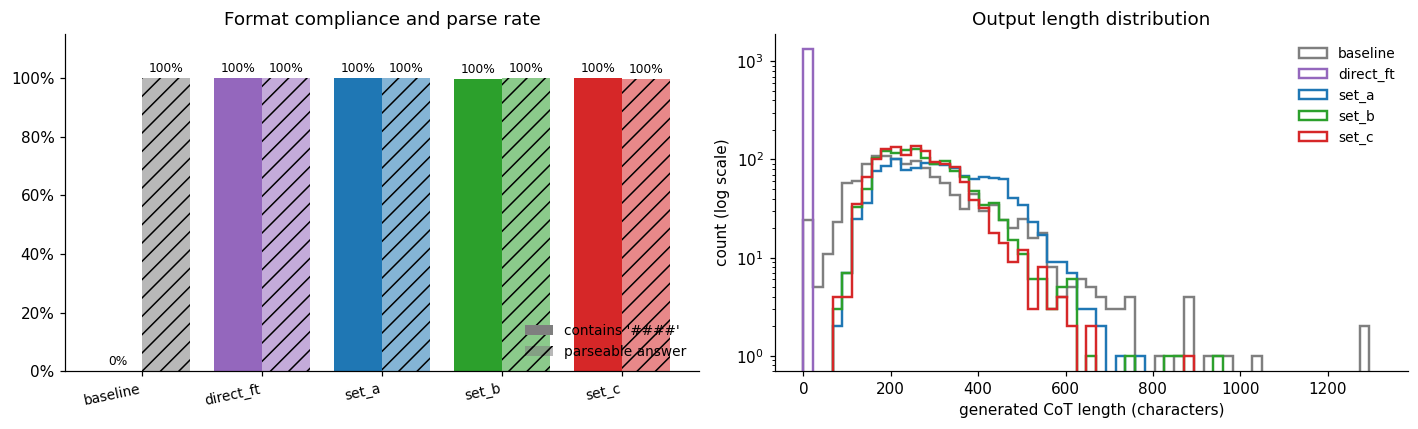

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))

# Panel 1 — format compliance + parse rate
ax = axes[0]
x = np.arange(len(CONDS)); w = 0.4
fmt   = [r["format_compliance"] for r in rows]
parse = [r["parse_rate"]        for r in rows]
b1 = ax.bar(x - w/2, fmt,   w, label="contains '####'", color=[PALETTE[c] for c in CONDS])
b2 = ax.bar(x + w/2, parse, w, label="parseable answer", color=[PALETTE[c] for c in CONDS], alpha=0.55, hatch="//")
for bars in (b1, b2):
    for rr in bars:
        ax.text(rr.get_x() + rr.get_width()/2, rr.get_height() + 0.01,
                f"{rr.get_height():.0%}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([c.replace("student_", "") for c in CONDS], rotation=12, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_title("Format compliance and parse rate")
ax.legend(frameon=False, loc="lower right", fontsize=9)

# Panel 2 — CoT length distribution (log-y to handle the direct_ft vs CoT scale gap)
ax = axes[1]
max_len = max(max(r["_cot_chars"]) for r in rows)
bins = np.linspace(0, max_len + 25, 60)
for r in rows:
    ax.hist(r["_cot_chars"], bins=bins, histtype="step", linewidth=1.6,
            label=r["condition"].replace("student_", ""), color=PALETTE[r["condition"]])
ax.set_yscale("log")
ax.set_xlabel("generated CoT length (characters)")
ax.set_ylabel("count (log scale)")
ax.set_title("Output length distribution")
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()


**Observations.**

- **All four students are at ~100% `####` compliance.** The v2 decoding fix is doing its job; we are no longer losing answers to truncated repetition loops, which was the v1 failure mode documented in `doc/Current Notebook.md`.
- **Parse rate is ~100% everywhere** (the baseline scores 100% because `parse_answer` falls back to the *last number in the string* when `####` is absent). So no condition is being unfairly penalised for missing markers.
- **Direct FT collapses the chain to ~7 characters** (visible as the spike at the left edge of the length panel). The student has learned the `#### N` token sequence and emits nothing else. From a pure-accuracy perspective this is a *win*, but it tells us the model isn't reasoning — it's pattern-matching the question to a memorised answer prior. This is an **issue** for the project's narrative: if Direct FT is the accuracy ceiling, accuracy alone clearly doesn't capture reasoning quality.
- **Set A's distribution has a long right tail** that Set B and Set C don't have. Set A's noisier chains include verbose teacher chains; the student inherits that verbosity. None of the tails reach the 512-token cap, so we are no longer truncating mid-thought.
- **Baseline length is bimodal** — short for direct numerical questions, long for word problems where it produces a free-form chain without the `####` marker.


## 6. Qualitative side-by-side

Three randomly-chosen test problems. Each panel shows the gold answer and what every condition produced, with a check mark on whether the parsed final answer is correct.

In [10]:
rng = np.random.default_rng(7)
rec = {c: load_records(c) for c in CONDS}
n = len(rec["baseline"])
idxs = rng.choice(n, size=3, replace=False)

for i in idxs:
    q = rec["baseline"][i]["question"]
    g = rec["baseline"][i]["gold_answer"]
    print("=" * 100)
    print(f"Q ({i}): {q}")
    print(f"GOLD: {g}")
    for c in CONDS:
        r = rec[c][i]
        ok = (r["parsed_answer"] is not None
              and r["gold_answer"] is not None
              and abs(r["parsed_answer"] - r["gold_answer"]) < 1e-6)
        flag = "OK" if ok else " X"
        cot = r["generated_cot"] or ""
        cot = cot if len(cot) < 380 else cot[:370] + " ..."
        print(f"\n  [{flag}] {c:22s}  parsed={r['parsed_answer']}")
        print(f"        {cot}")
    print()


Q (1244): Audrey has to take two math tests to pass 6th grade. She must correctly answer 70% of the total questions to move on to the 7th grade. The first test has 70 questions and she gets 60% of them correct. The second test has 40 questions. How many questions does she need to get right on the second test to move onto the 7th grade?
GOLD: 35.0

  [ X] baseline                parsed=220.0
        First find how many questions are correct on the first test: 70 questions / 70% = 20 questions. Then find how many answers she gets on the second test: 40 questions / 40% = 10 questions. Now multiply the number of questions by the number of correct answers to find the total number of questions: 20 questions + 10 questions = 40 questions. Now subtract the number of wro ...

  [ X] student_direct_ft       parsed=60.0
        #### 60

  [ X] student_set_a           parsed=120.0
        Audrey has to take two math tests to pass 6th grade. She must correctly answer 70% of the total questions to m

**Observations.**

- **Surface fluency is high.** All three CoT students produce English that *looks* like step-by-step reasoning — they introduce variables, write equations, sum them up, and emit `#### N` at the end. That's a meaningful change from the baseline's free-form prose.
- **Failures are almost always *premise* failures**, not arithmetic failures: the student picks the wrong inputs ("3 * 4 = 12" when the question never said to multiply those quantities), then computes correctly from there. This is exactly why eval-time calculator-rewriting moved no needle — the calculator can fix `5 + 6 = 12`, but it can't tell the model to use `5+6` instead of `5*6` in the first place.
- **Direct FT often gets the right answer for the wrong reason.** It just emits a number; sometimes the prior is right, sometimes it isn't. This is the cleanest demonstration in the data of the project's central thesis: a number-only output can score at parity with a reasoned output without doing any reasoning.
- **Set C's outputs read more *consistently* than Set B's**, even on problems both get wrong — fewer nonsense intermediate steps. ReCEval's intra-step entailment metric should pick this up.


## 7. Synthesis

### Good points

1. **The pipeline is healthy end-to-end.** Filter sizes match expectations, all four students train cleanly with monotonically decreasing loss, all five conditions produce 1,319 generations with ~100% format compliance.
2. **The v2 decoding fix worked.** Looping pathology from v1 is gone; chains terminate naturally; parse rate is at the ceiling.
3. **Set A reproduces Ho et al.'s 2.50% exactly.** The implementation is faithful — any underperformance is a property of the setup, not a bug.
4. **The CoT student ranking is the *right* ranking.** Set C (process-aware) > Set B (answer-only) > Set A (unfiltered). The calculator-corrected filter is doing what was hypothesised.
5. **Direct FT is in place** as a properly-conditioned control. It quantifies the reasoning-free accuracy ceiling for this model size — a key piece of the project's punch line.

### Issues / open concerns

1. **All CoT students are below the un-finetuned baseline (4.32%).** The gap is now small (~1–2 points) versus the catastrophic v1 collapse, but the direction is still backwards. This is the central tension that ReCEval needs to explain: are these students producing better *reasoning* even though they get the answer wrong more often?
2. **`accuracy_w_calc` is a no-op everywhere.** Eval-time calculator-rewriting catches zero additional correct answers. Failures are dominated by *premise* errors (wrong inputs into the equation), which a surface-level calculator pass cannot rescue. This makes Stage 5b's intra-step + informativeness metrics critical — they target exactly this failure mode.
3. **Direct FT got the highest accuracy by emitting no reasoning.** Median output length is 7 characters. If the project's only metric were accuracy, the conclusion would be "don't do CoT distillation" — which is exactly the artefact the dual-metric (accuracy + ReCEval) framing is designed to expose.
4. **Set B's selected checkpoint is the early-stopping minimum (epoch 7.0)** rather than the final-epoch checkpoint. Mentioned for completeness; the eval loss difference vs the final checkpoint is < 0.01.

### Open questions for the next stage

- **Does ReCEval rank the students differently than accuracy does?** Specifically, does Set C *also* dominate on intra-step entailment and informativeness, and how does Direct FT score on a metric that *requires* multi-step output?
- **Where in the chain do CoT students fail?** Per-step ReCEval scores (rather than just the chain-level `min`) will tell us whether failures cluster at step 1 (premise error) or accumulate later.
- **Is the baseline's free-form chain actually less coherent than the students', once we look past the missing `####`?** If the baseline scores worse on intra-step entailment despite having higher accuracy, that is the cleanest version of the project's headline finding.

### Next checkpoint

**Stage 5b — ReCEval scoring** on all five conditions, using `outputs/generations/{condition}.jsonl` as input. The goal is `outputs/eval_results/receval_summary.csv` with per-condition `min_intra`, `min_inter`, `min_info` plus per-example arrays for plot-and-audit.
